# Nikkei Moving Averages Analysis

This notebook analyzes Nikkei data using moving averages to identify crossovers and simulate weekly trades.

In [ ]:
import sys
import argparse
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

In [11]:
%matplotlib inline

In [17]:
def NikkeiMovingAverages(
    file_path: str = "Nikkei---Moving-averages.xlsx", short: int = 15, long: int = 150
):
    df = pd.read_excel(file_path)

    # Basic validation
    if df.shape[1] < 2:
        raise SystemExit("Expected at least 2 columns: date + price column")

    # Identify columns
    date_col = df.columns[0]
    price_col = df.columns[1]

    # Convert first column to datetime
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    if df[date_col].isna().any():
        print("Warning: Some date values could not be parsed and are NaT")

    # Work on a copy and compute moving averages from the price column
    df = df[[date_col, price_col]].copy()
    df = df.rename(columns={price_col: "Close"})

    short_col = f"MA{short}"
    long_col = f"MA{long}"
    df[short_col] = df["Close"].rolling(short).mean()
    df[long_col] = df["Close"].rolling(long).mean()

    # mask where short MA > long MA
    mask = df[short_col] > df[long_col]

    # Print matching dates
    print(f"Dates where {short_col} > {long_col}:")
    for d in df.loc[mask, date_col].dt.date.dropna():
        print(d.isoformat())

    # --- Weekly crossover trade analysis ---
    df_week = df.set_index(date_col)[["Close"]].resample("W-FRI").last()
    short_weeks = max(1, int(round(short / 5)))
    long_weeks = max(1, int(round(long / 5)))
    short_w_col = f"MA{short_weeks}w"
    long_w_col = f"MA{long_weeks}w"
    df_week[short_w_col] = df_week["Close"].rolling(short_weeks).mean()
    df_week[long_w_col] = df_week["Close"].rolling(long_weeks).mean()

    mask_w = df_week[short_w_col] > df_week[long_w_col]

    # iterate weekly data chronologically and open only one trade at a time
    trades = []
    in_pos = False
    entry_date = None
    entry_price = None

    for idx in df_week.index:
        try:
            short_above = bool(mask_w.loc[idx])
        except Exception:
            continue

        price_val = df_week.loc[idx, "Close"]
        if isinstance(price_val, pd.Series):
            price_val = price_val.iloc[0]
        if pd.isna(price_val):
            continue
        price = float(price_val)

        if not in_pos and short_above:
            in_pos = True
            entry_date = idx
            entry_price = price
        elif in_pos and not short_above:
            exit_date = idx
            exit_price = price
            gain = exit_price - entry_price
            rtn = gain / entry_price
            trades.append(
                (
                    entry_date.date().isoformat(),
                    exit_date.date().isoformat(),
                    float(entry_price),
                    float(exit_price),
                    float(gain),
                    float(rtn),
                )
            )
            in_pos = False
            entry_date = None
            entry_price = None

    # Print trade list and summary
    if trades:
        print(f"\nWeekly trades based on {short_weeks}-wk vs {long_weeks}-wk MAs:")
        total = 0.0
        total_money = 0.0
        for t in trades:
            ed, xd, ep, xp, g, r = t
            print(
                f"Entry {ed} @ {ep:.2f}, Exit {xd} @ {xp:.2f}, Gain {g:.2f}, Return {r:.4f}"
            )
            total += r
            total_money += g
        cum = 1.0
        for _, _, _, _, _, r in trades:
            cum *= 1 + r
        cum_return = cum - 1
        print(f"Sum of returns: {total:.4f}")
        print(f"Total money gained (sum of gains): {total_money:.2f}")
        print(f"Cumulative return (compounded): {cum_return:.4f}")
        initial_investment = 100000
        final_wealth = initial_investment * (1 + cum_return)
        print(f"Final wealth from 100,000 Yen investment: {final_wealth:.2f} Yen\n")
    else:
        print("\nNo completed weekly trades found for the selected windows.\n")

    # Plot Close and the two MAs and shade where short > long
    fig, ax = plt.subplots()
    ax.plot(df[date_col], df["Close"], label="Close")
    ax.plot(df[date_col], df[short_col], label=short_col)
    ax.plot(df[date_col], df[long_col], label=long_col)

    ax.fill_between(
        df[date_col],
        df[short_col],
        df[long_col],
        where=mask,
        interpolate=True,
        color="gray",
        alpha=0.3,
        label=f"{short_col} > {long_col}",
    )

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.set_xlabel(date_col)
    ax.set_ylabel("Price")
    ax.set_title(f"{price_col} Close, {short_col} and {long_col}")
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

Dates where MA15 > MA150:
1994-04-25
1994-05-02
1994-05-09
1994-05-16
1994-05-23
1994-05-30
1994-06-06
1994-06-13
1994-06-20
1994-06-27
1994-07-04
1994-07-11
1994-07-18
1994-07-25
1994-08-01
1994-08-08
1994-08-15
1994-08-22
1994-08-29
1994-09-05
1994-09-12
1994-09-19
1994-09-26
1994-10-03
1994-10-10
1994-10-17
1994-10-24
1994-10-31
1994-11-07
1994-11-14
1994-11-21
1994-11-28
1994-12-05
1994-12-12
1994-12-19
1994-12-26
1995-01-02
1995-01-09
1995-01-16
1995-01-23
1995-01-30
1995-02-06
1995-02-13
1995-02-20
1996-01-22
1996-01-29
1996-02-05
1996-02-12
1996-02-19
1996-02-26
1996-03-04
1996-03-11
1996-03-18
1996-03-25
1996-04-01
1996-04-08
1996-04-15
1996-04-22
1996-04-29
1996-05-06
1996-05-13
1996-05-20
1996-05-27
1996-06-03
1996-06-10
1996-06-17
1996-06-24
1996-07-01
1996-07-08
1996-07-15
1996-07-22
1996-07-29
1996-08-05
1996-08-12
1996-08-19
1996-08-26
1996-09-02
1996-09-09
1996-09-16
1996-09-23
1996-09-30
1996-10-07
1996-10-14
1996-10-21
1996-10-28
1996-11-04
1996-11-11
1996-11-18
1996-1

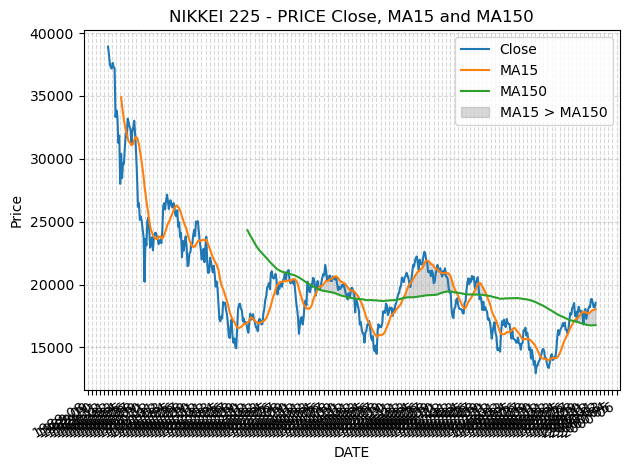

In [18]:
# Call the main function with default parameters
NikkeiMovingAverages()

In [ ]:
def compute_wealth(short_weeks, long_weeks, file_path="Nikkei---Moving-averages.xlsx"):
    df = pd.read_excel(file_path)

    # Basic validation
    if df.shape[1] < 2:
        raise SystemExit("Expected at least 2 columns: date + price column")

    # Identify columns
    date_col = df.columns[0]
    price_col = df.columns[1]

    # Convert first column to datetime
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # Work on a copy
    df = df[[date_col, price_col]].copy()
    df = df.rename(columns={price_col: "Close"})

    # Weekly data
    df_week = df.set_index(date_col)[["Close"]].resample("W-FRI").last()
    short_w_col = f"MA{short_weeks}w"
    long_w_col = f"MA{long_weeks}w"
    df_week[short_w_col] = df_week["Close"].rolling(short_weeks).mean()
    df_week[long_w_col] = df_week["Close"].rolling(long_weeks).mean()

    mask_w = df_week[short_w_col] > df_week[long_w_col]

    # Trades
    trades = []
    in_pos = False
    entry_price = None

    for idx in df_week.index:
        try:
            short_above = bool(mask_w.loc[idx])
        except Exception:
            continue

        price_val = df_week.loc[idx, "Close"]
        if isinstance(price_val, pd.Series):
            price_val = price_val.iloc[0]
        if pd.isna(price_val):
            continue
        price = float(price_val)

        if not in_pos and short_above:
            in_pos = True
            entry_price = price
        elif in_pos and not short_above:
            exit_price = price
            rtn = (exit_price - entry_price) / entry_price
            trades.append(rtn)
            in_pos = False
            entry_price = None

    if trades:
        cum = 1.0
        for r in trades:
            cum *= 1 + r
        cum_return = cum - 1
        final_wealth = 100000 * (1 + cum_return)
    else:
        final_wealth = 100000

    return final_wealth

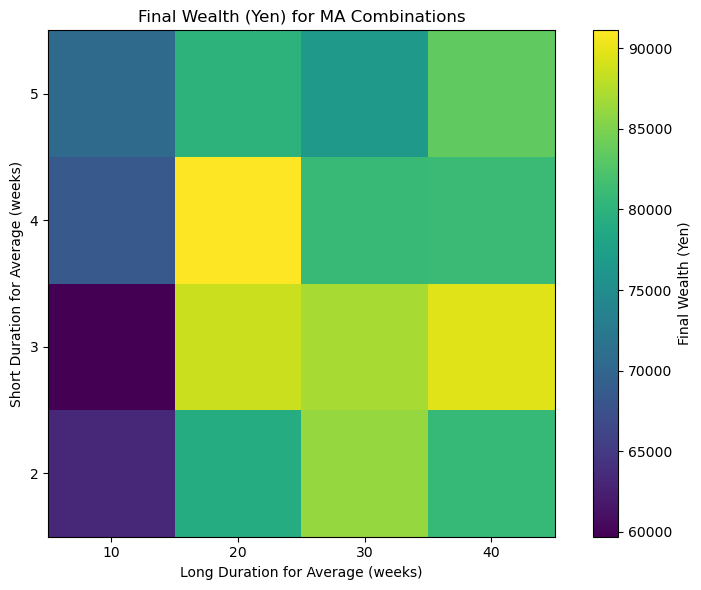

In [16]:
import numpy as np

# Define the values to explore
short_vals = [2, 3, 4, 5]
long_vals = [10, 20, 30, 40]

# Initialize results matrix
results = np.zeros((len(short_vals), len(long_vals)))

# Compute for each combination
for i, sw in enumerate(short_vals):
    for j, lw in enumerate(long_vals):
        results[i, j] = compute_wealth(sw, lw)

# Plot the results
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(results, cmap='viridis', origin='lower')
ax.set_xticks(range(len(long_vals)))
ax.set_yticks(range(len(short_vals)))
ax.set_xticklabels(long_vals)
ax.set_yticklabels(short_vals)
ax.set_xlabel('Long Duration for Average (weeks)')
ax.set_ylabel('Short Duration for Average (weeks)')
ax.set_title('Final Wealth (Yen) for MA Combinations')
plt.colorbar(cax, label='Final Wealth (Yen)')
plt.tight_layout()
plt.show()

In [24]:
import yfinance as yf
# Define parameters for the new dataframe
ticker = "AAPL"  # Example ticker, change as needed
period = "10y"   # Example period
short = 15       # Short MA window
long = 63        # Long MA window

# Download historical data (robust: try download(), fall back to Ticker.history())
df = None
try:
    df = yf.download(ticker, period=period, progress=False)
except Exception as e:
    print(f"Primary download failed: {e}")

if df is None or (hasattr(df, "empty") and df.empty):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period)
    except Exception as e:
        print(f"Fallback history failed: {e}")
        df = None

if df is None or (hasattr(df, "empty") and df.empty):
    sys.exit(
        "No data downloaded for ticker={}. Check ticker or network.".format(ticker)
    )

# Keep Close and compute moving averages similar to the Nikkei moving-averages exercise
# short and long are rolling window sizes in trading days (default: 3 weeks=15, 3 months≈63)
df = df[["Close"]].copy()
short_col = f"MA{short}"
long_col = f"MA{long}"
df[short_col] = df["Close"].rolling(short).mean()
df[long_col] = df["Close"].rolling(long).mean()

df = df.reset_index()

In [ ]:
# Run the same weekly crossover trade strategy on the downloaded ticker dataframe
def run_weekly_crossover(df, short, long, starting_capital=100000):
    # Ensure data has Date and Close
    if 'Date' not in df.columns:
        raise ValueError('DataFrame must have Date index or Date column')

    if 'Close' not in df.columns:
        raise ValueError('DataFrame must have Close column')

    df = df.copy()

    # If DataFrame has Date column, set it as index
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date')

    # Handle yfinance multi-index columns, e.g. Price/Close and Ticker
    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            df = df[[('Close', ticker)]].copy(); df.columns = ['Close']
        elif ('Close', '') in df.columns:
            df = df[[('Close', '')]].copy(); df.columns = ['Close']
        elif 'Close' in df.columns.get_level_values(0):
            df = df.xs('Close', axis=1, level=0)
            if isinstance(df, pd.Series):
                df = df.to_frame('Close')
            else:
                df.columns = ['Close']
        else:
            raise ValueError('Cannot find Close data in multiindex columns')

    # In case Close is not in columns by now, check other formats
    if 'Close' not in df.columns:
        raise ValueError('Close column is required in DataFrame')

    # Weekly resampling by Friday close
    df_week = df[['Close']].resample('W-FRI').last().dropna()
    short_w = max(1, int(round(short / 5)))
    long_w = max(1, int(round(long / 5)))

    df_week[f'MA{short_w}w'] = df_week['Close'].rolling(short_w).mean()
    df_week[f'MA{long_w}w'] = df_week['Close'].rolling(long_w).mean()

    df_week['signal'] = (df_week[f'MA{short_w}w'] > df_week[f'MA{long_w}w']).astype(int)
    df_week['signal_shift'] = df_week['signal'].shift(1).fillna(0).astype(int)
    df_week['entry'] = ((df_week['signal'] == 1) & (df_week['signal_shift'] == 0)).astype(int)
    df_week['exit'] = ((df_week['signal'] == 0) & (df_week['signal_shift'] == 1)).astype(int)

    trades = []
    in_pos = False
    entry_price = None
    entry_date = None

    for date, row in df_week.iterrows():
        if row['entry'] == 1 and not in_pos:
            in_pos = True
            entry_date = date
            entry_price = row['Close']
        elif row['exit'] == 1 and in_pos:
            exit_price = row['Close']
            exit_date = date
            r = (exit_price - entry_price) / entry_price
            trades.append({'entry_date': entry_date, 'exit_date': exit_date, 'entry_price': entry_price, 'exit_price': exit_price, 'return': r})
            in_pos = False
            entry_price = None
            entry_date = None

    if in_pos and entry_price is not None:
        exit_price = df_week['Close'].iloc[-1]
        exit_date = df_week.index[-1]
        r = (exit_price - entry_price) / entry_price
        trades.append({'entry_date': entry_date, 'exit_date': exit_date, 'entry_price': entry_price, 'exit_price': exit_price, 'return': r})

    trades_df = pd.DataFrame(trades)
    cumulative = trades_df['return'].add(1).prod() if not trades_df.empty else 1.0
    cum_return = cumulative - 1
    final_wealth = starting_capital * (1 + cum_return)

    return {
        'df_week': df_week,
        'trades_df': trades_df,
        'cumulative_return': cum_return,
        'final_wealth': final_wealth,
    }


# Example usage next cell will to inspect entries/exits and operations


SP500 result 179067.98942908418 return 0.7906798942908417
       entry       exit  entry_price   exit_price    return
0 2016-09-16 2016-09-16  2129.899902  2139.159912  0.004348
1 2017-04-21 2017-04-21  2213.350098  2348.689941  0.061147
2 2017-08-25 2017-08-25  2384.199951  2443.050049  0.024683
3 2018-02-16 2018-02-16  2476.550049  2732.219971  0.103236
4 2018-03-23 2018-03-23  2786.570068  2588.260010 -0.071166


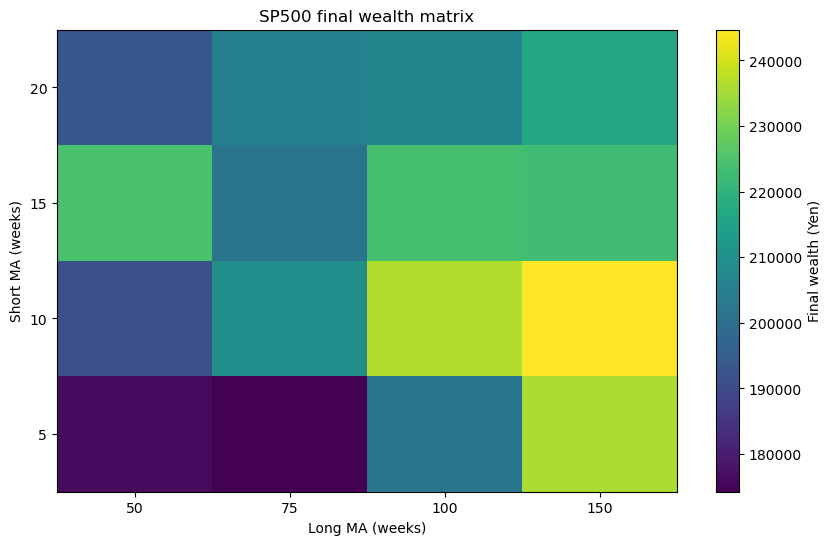

In [48]:
def backtest_ticker(ticker, period='10y', short=15, long=63, starting_capital=100000):
    df = None
    try:
        df = yf.download(ticker, period=period, progress=False)
    except Exception as e:
        print(f"Primary download failed: {e}")

    if df is None or (hasattr(df, 'empty') and df.empty):
        try:
            tk = yf.Ticker(ticker)
            df = tk.history(period=period)
        except Exception as e:
            print(f"Fallback history failed: {e}")
            df = None

    if df is None or (hasattr(df, 'empty') and df.empty):
        raise RuntimeError(f"No data downloaded for ticker {ticker}")

    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date')

    if isinstance(df.columns, pd.MultiIndex):
        if ('Close', ticker) in df.columns:
            df = df[[('Close', ticker)]].copy()
            df.columns = ['Close']
        elif ('Close', '') in df.columns:
            df = df[[('Close', '')]].copy()
            df.columns = ['Close']
        elif 'Close' in df.columns.get_level_values(0):
            df = df.xs('Close', axis=1, level=0)
            if isinstance(df, pd.Series):
                df = df.to_frame('Close')
            else:
                df.columns = ['Close']
        else:
            raise RuntimeError('Close not found in MultiIndex columns')

    if 'Close' not in df.columns:
        raise RuntimeError('Close column missing in df')

    short_w = max(1, int(round(short / 5)))
    long_w = max(1, int(round(long / 5)))

    df_week = df[['Close']].resample('W-FRI').last().dropna()
    df_week[f'MA{short_w}w'] = df_week['Close'].rolling(short_w).mean()
    df_week[f'MA{long_w}w'] = df_week['Close'].rolling(long_w).mean()

    mask = df_week[f'MA{short_w}w'] > df_week[f'MA{long_w}w']
    in_pos = False
    entry_price = None
    trade_records = []

    for date, row in df_week.iterrows():
        price = row['Close']
        if pd.isna(price):
            continue

        if not in_pos and mask.loc[date]:
            in_pos = True
            entry_price = price
        elif in_pos and not mask.loc[date]:
            exit_price = price
            rtn = (exit_price - entry_price) / entry_price
            trade_records.append({'entry': date, 'exit': date, 'entry_price': entry_price, 'exit_price': exit_price, 'return': rtn})
            in_pos = False
            entry_price = None

    if in_pos and entry_price is not None:
        exit_price = df_week['Close'].iloc[-1]
        rtn = (exit_price - entry_price) / entry_price
        trade_records.append({'entry': df_week.index[-1], 'exit': df_week.index[-1], 'entry_price': entry_price, 'exit_price': exit_price, 'return': rtn})

    trades_df = pd.DataFrame(trade_records)
    cumulative = trades_df['return'].add(1).prod() if not trades_df.empty else 1.0
    cum_return = cumulative - 1
    final_wealth = starting_capital * (1 + cum_return)

    return {
        'ticker': ticker,
        'short': short,
        'long': long,
        'period': period,
        'trades_df': trades_df,
        'cumulative_return': cum_return,
        'final_wealth': final_wealth,
    }


# Run SP500 ticker backtest
sp500_ticker = '^GSPC'
sp_res = backtest_ticker(sp500_ticker, period='10y', short=15, long=63)
print('SP500 result', sp_res['final_wealth'], 'return', sp_res['cumulative_return'])
print(sp_res['trades_df'].head())

# 4x4 grid
short_vals = [5, 10, 15, 20]
long_vals = [50, 75, 100, 150]
wealth_grid = np.zeros((len(short_vals), len(long_vals)))

for i, sw in enumerate(short_vals):
    for j, lw in enumerate(long_vals):
        out = backtest_ticker(sp500_ticker, period='10y', short=sw, long=lw)
        wealth_grid[i, j] = out['final_wealth']

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(wealth_grid, origin='lower', cmap='viridis', aspect='auto')
ax.set_xticks(range(len(long_vals)))
ax.set_xticklabels(long_vals)
ax.set_yticks(range(len(short_vals)))
ax.set_yticklabels(short_vals)
ax.set_xlabel('Long MA (weeks)')
ax.set_ylabel('Short MA (weeks)')
ax.set_title('SP500 final wealth matrix')
plt.colorbar(cax, label='Final wealth (Yen)')
plt.show()

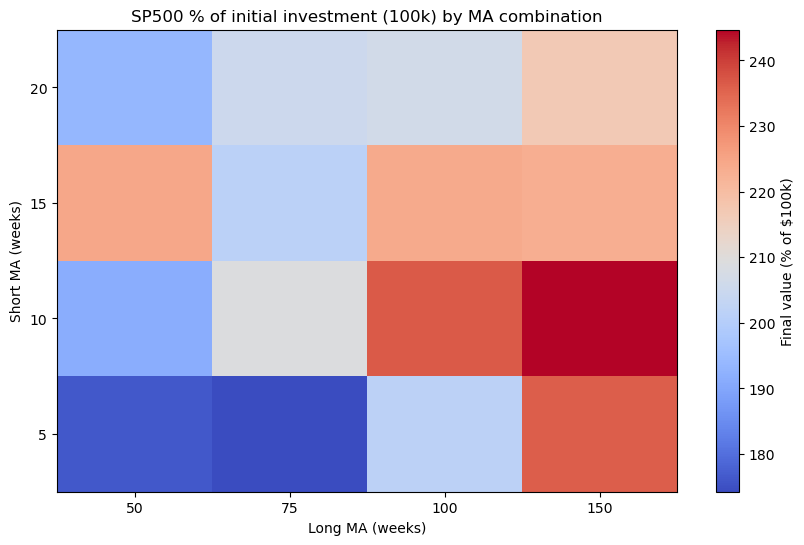

In [49]:
# Plot the same 4x4 matrix in percentage terms relative to initial investment ($100k)
percent_grid = (wealth_grid / 100000.0) * 100.0

fig, ax = plt.subplots(figsize=(10, 6))
cax = ax.imshow(percent_grid, origin='lower', cmap='coolwarm', aspect='auto')
ax.set_xticks(range(len(long_vals)))
ax.set_xticklabels(long_vals)
ax.set_yticks(range(len(short_vals)))
ax.set_yticklabels(short_vals)
ax.set_xlabel('Long MA (weeks)')
ax.set_ylabel('Short MA (weeks)')
ax.set_title('SP500 % of initial investment (100k) by MA combination')
plt.colorbar(cax, label='Final value (% of $100k)')
plt.show()

In [59]:
# Use the improved function to inspect the crossover operations
sp500_ticker = '^GSPC'
sp_short = 15 # 3 weeks
sp_long = 5*30 # 30 weeks 

result = run_weekly_crossover(df, short=sp_short, long=sp_long)

print('Final wealth:', result['final_wealth'])
print('Cumulative return:', result['cumulative_return'])

# Entry/exit trade table
print(result['trades_df'].head(20))

# Crossover points in weekly data
display(result['df_week'][['Close', f'MA{max(1, int(round(sp_short/5)))}w', f'MA{max(1, int(round(sp_long/5)))}w', 'entry', 'exit']].tail(20))

Final wealth: 314817.5564276355
Cumulative return: 2.148175564276355
   entry_date  exit_date  entry_price  exit_price    return
0  2016-10-28 2018-02-09    26.052542   36.744911  0.410416
1  2018-02-23 2018-04-06    41.229664   39.556988 -0.040570
2  2018-04-13 2018-04-27    41.048771   38.133324 -0.071024
3  2018-05-04 2018-11-23    43.186600   40.916389 -0.052567
4  2019-03-29 2020-03-20    45.303852   55.390327  0.222641
5  2020-04-24 2021-03-12    68.372894  117.882668  0.724114
6  2021-04-09 2021-05-28   129.541382  121.575737 -0.061491
7  2021-06-18 2022-04-29   127.283272  154.463013  0.213537
8  2022-08-05 2022-09-16   162.470749  148.075836 -0.088600
9  2022-11-25 2022-12-02   145.772369  145.477127 -0.002025
10 2023-02-10 2023-09-29   148.853531  169.226730  0.136867
11 2023-11-17 2024-03-01   187.739685  178.039688 -0.051667
12 2024-05-17 2025-01-24   188.412796  221.569641  0.175980
13 2025-02-14 2025-03-14   243.538544  212.563553 -0.127187
14 2025-08-08 2026-03-13   228.

,Close,MA3w,MA30w,entry,exit
Date,,,,,
2025-11-21,271.236176,270.450256,228.200051,0,0
2025-11-28,278.589325,273.993612,230.671065,0,0
2025-12-05,278.519379,276.114960,233.366095,0,0
2025-12-12,278.019867,278.376190,235.612789,0,0
2025-12-19,273.414185,276.651143,238.237342,0,0
2025-12-26,273.144409,274.859487,240.667467,0,0
2026-01-02,270.756653,272.438416,242.915977,0,0
2026-01-09,259.127533,267.676198,245.025096,0,0
2026-01-16,255.291122,261.725103,246.855126,0,0


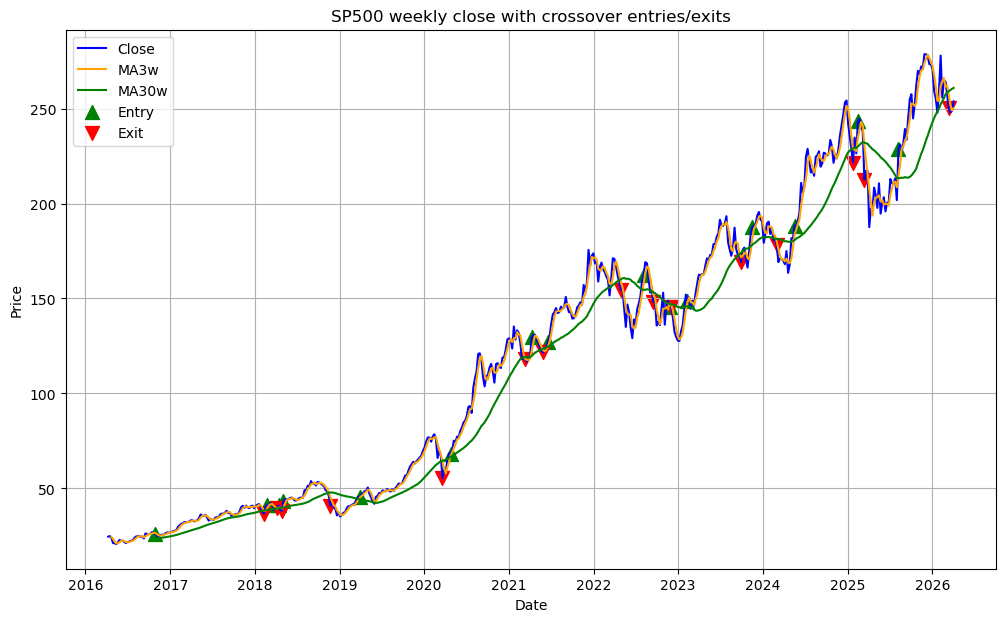

In [60]:
# Plot price series with entry/exit markers
weekly = result['df_week']
entries = weekly[weekly['entry'] == 1]
exits = weekly[weekly['exit'] == 1]

plt.figure(figsize=(12,7))
plt.plot(weekly.index, weekly['Close'], label='Close', color='blue')
plt.plot(weekly.index, weekly[f'MA{max(1,int(round(sp_short/5)))}w'], label=f'MA{max(1,int(round(sp_short/5)))}w', color='orange')
plt.plot(weekly.index, weekly[f'MA{max(1,int(round(sp_long/5)))}w'], label=f'MA{max(1,int(round(sp_long/5)))}w', color='green')
plt.scatter(entries.index, entries['Close'], marker='^', color='g', s=100, label='Entry')
plt.scatter(exits.index, exits['Close'], marker='v', color='r', s=100, label='Exit')
plt.title('SP500 weekly close with crossover entries/exits')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Santander result 206637.46204434882 return 1.0663746204434883
       entry       exit  entry_price  exit_price    return
0 2017-08-25 2017-08-25     3.114926    3.950347  0.268199
1 2017-10-27 2017-10-27     4.265941    4.144451 -0.028479
2 2017-11-17 2017-11-17     4.153907    3.986616 -0.040273
3 2017-12-29 2017-12-29     4.068806    3.985162 -0.020557
4 2018-03-09 2018-03-09     4.304469    4.010406 -0.068316


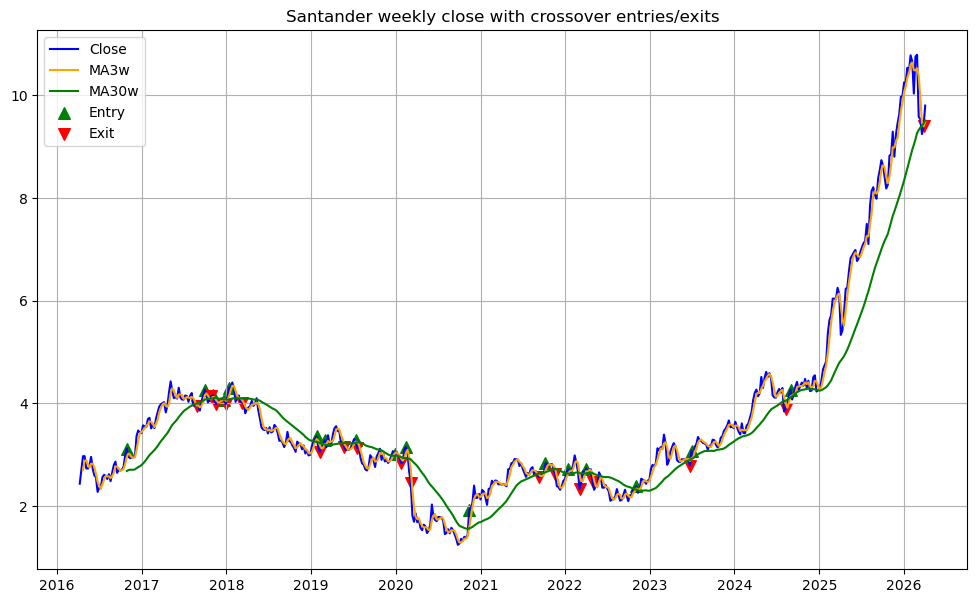

In [61]:
# Run same strategy on Santander (Madrid listing)
san_ticker = 'SAN.MC'

san_result = backtest_ticker(san_ticker, period='10y', short=sp_short, long=sp_long)
print('Santander result', san_result['final_wealth'], 'return', san_result['cumulative_return'])
print(san_result['trades_df'].head())

# Optional plot
weekly_san = run_weekly_crossover(yf.download(san_ticker, period='10y', progress=False).reset_index(), short=sp_short, long=sp_long)['df_week']
entries_san = weekly_san[weekly_san['entry'] == 1]
exits_san = weekly_san[weekly_san['exit'] == 1]

plt.figure(figsize=(12,7))
plt.plot(weekly_san.index, weekly_san['Close'], label='Close', color='blue')
plt.plot(weekly_san.index, weekly_san[f'MA{max(1,int(round(sp_short/5)))}w'], label=f'MA{max(1,int(round(sp_short/5)))}w', color='orange')
plt.plot(weekly_san.index, weekly_san[f'MA{max(1,int(round(sp_long/5)))}w'], label=f'MA{max(1,int(round(sp_long/5)))}w', color='green')
plt.scatter(entries_san.index, entries_san['Close'], marker='^', color='g', s=70, label='Entry')
plt.scatter(exits_san.index, exits_san['Close'], marker='v', color='r', s=70, label='Exit')
plt.title('Santander weekly close with crossover entries/exits')
plt.legend()
plt.grid(True)
plt.show()


=== ITX.MC ===
ITX.MC result 144645.23 return 0.446452
       entry       exit  entry_price  exit_price    return
0 2017-01-20 2017-01-20    24.093185   23.314777 -0.032308
1 2017-08-25 2017-08-25    24.330095   25.374083  0.042909
2 2018-09-07 2018-09-07    22.092957   19.607885 -0.112483
3 2019-05-31 2019-05-31    21.154158   19.334639 -0.086012
4 2020-03-06 2020-03-06    20.476229   21.915970  0.070313


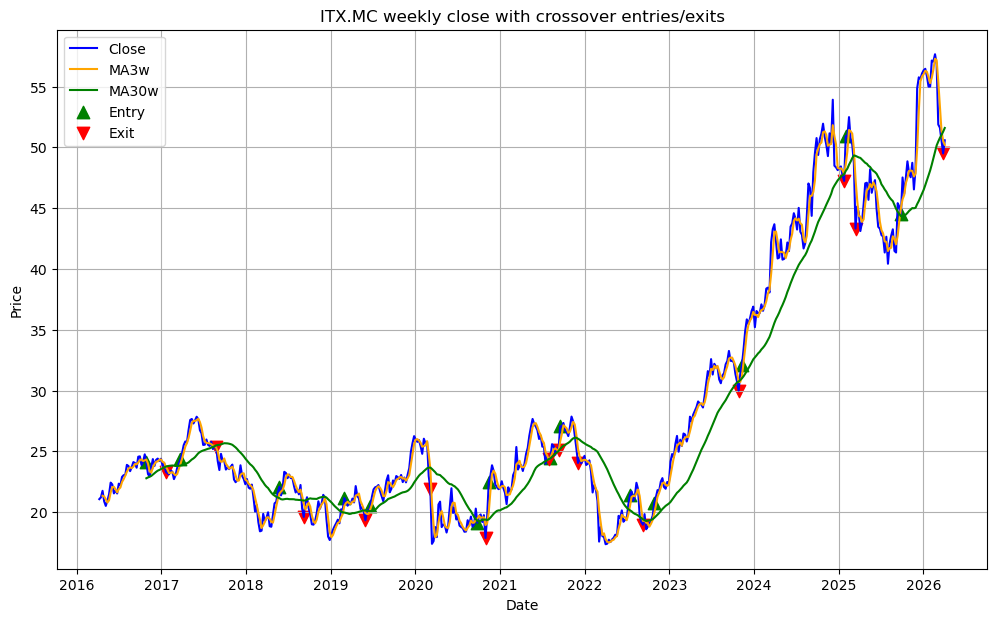


=== SCYR.MC ===
SCYR.MC result 128706.75 return 0.287068
       entry       exit  entry_price  exit_price    return
0 2017-07-14 2017-07-14     1.385269    1.540885  0.112337
1 2018-03-23 2018-03-23     1.595675    1.460179 -0.084915
2 2018-10-19 2018-10-19     1.602467    1.682829  0.050148
3 2020-03-06 2020-03-06     1.606193    1.649642  0.027051
4 2020-10-16 2020-10-16     1.515334    1.257340 -0.170256


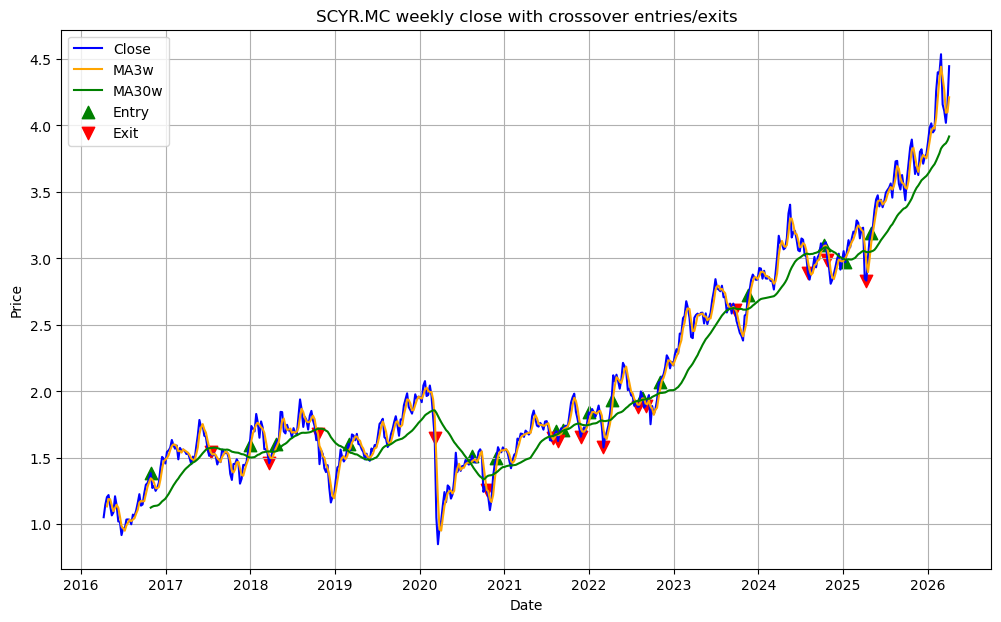

In [62]:
# Run same strategy for Inditex and Sacyr
symbols = ['ITX.MC', 'SCYR.MC']

for sym in symbols:
    print('\n===', sym, '===')
    res = backtest_ticker(sym, period='10y', short=sp_short, long=sp_long)
    print(f"{sym} result {res['final_wealth']:.2f} return {res['cumulative_return']:.6f}")
    print(res['trades_df'].head())

    df_source = None
    try:
        df_source = yf.download(sym, period='10y', progress=False)
    except Exception as e:
        print(f"Download for {sym} failed: {e}")

    if df_source is None or (hasattr(df_source, 'empty') and df_source.empty):
        df_source = yf.Ticker(sym).history(period='10y')

    result = run_weekly_crossover(df_source.reset_index(), short=sp_short, long=sp_long)
    weekly = result['df_week']
    entries = weekly[weekly['entry'] == 1]
    exits = weekly[weekly['exit'] == 1]

    plt.figure(figsize=(12,7))
    plt.plot(weekly.index, weekly['Close'], label='Close', color='blue')
    plt.plot(weekly.index, weekly[f'MA{max(1,int(round(sp_short/5)))}w'], label=f'MA{max(1,int(round(sp_short/5)))}w', color='orange')
    plt.plot(weekly.index, weekly[f'MA{max(1,int(round(sp_long/5)))}w'], label=f'MA{max(1,int(round(sp_long/5)))}w', color='green')
    plt.scatter(entries.index, entries['Close'], marker='^', color='g', s=80, label='Entry')
    plt.scatter(exits.index, exits['Close'], marker='v', color='r', s=80, label='Exit')
    plt.title(f'{sym} weekly close with crossover entries/exits')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.show()